# E-Commerce Recommendation System
## KNN Candidate Retrieval + Rank Fusion

### Goal
Build a small recommendation system for 10 products.

The system will:
1. Represent products as vectors
2. Represent a user using interaction history
3. Use KNN to retrieve candidate products
4. Calculate multiple recommendation signals
5. Create separate rankings
6. Combine rankings using Reciprocal Rank Fusion (RRF)
7. Return the top 3 recommendations

### Architecture
User History → User Representation → KNN Candidate Retrieval → Multiple Ranking Signals → Rank Fusion → Top 3 Recommendations


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors

plt.rcParams['figure.figsize'] = (10, 6)


# 1. Our Products

Imagine an e-commerce website containing only 10 products.

In [2]:
products = {
    'P1': 'iPhone 15',
    'P2': 'Samsung Galaxy S24',
    'P3': 'Google Pixel 8',
    'P4': 'MacBook Air M2',
    'P5': 'Dell XPS 13',
    'P6': 'Sony WH-1000XM5',
    'P7': 'AirPods Pro',
    'P8': 'iPad Air',
    'P9': 'Apple Watch Series 9',
    'P10': 'Samsung Galaxy Watch 6',
}

product_ids = list(products.keys())
product_names=list(products.values())
products_df = pd.DataFrame({
    'product_id': product_ids,
    'product_name': product_names
})

products_df


,product_id,product_name
0,P1,iPhone 15
1,P2,Samsung Galaxy S24
2,P3,Google Pixel 8
3,P4,MacBook Air M2
4,P5,Dell XPS 13
5,P6,Sony WH-1000XM5
6,P7,AirPods Pro
7,P8,iPad Air
8,P9,Apple Watch Series 9
9,P10,Samsung Galaxy Watch 6


# 2. Representing Products as Vectors

A machine-learning system works with numerical representations.

For this toy model, every product has a 3-dimensional vector. In a real system, embeddings could have hundreds or thousands of dimensions.

**Important:** these vectors are manually created for learning; they are not produced by a real embedding model.

In [3]:
product_vectors = np.array([
    [0.90, 0.80, 0.10],  # P1 iPhone 15
    [0.85, 0.75, 0.10],  # P2 Samsung Galaxy S24
    [0.82, 0.72, 0.15],  # P3 Google Pixel 8
    [0.95, 0.20, 0.05],  # P4 MacBook Air M2
    [0.90, 0.18, 0.05],  # P5 Dell XPS 13
    [0.20, 0.85, 0.90],  # P6 Sony WH-1000XM5
    [0.30, 0.90, 0.85],  # P7 AirPods Pro
    [0.85, 0.35, 0.20],  # P8 iPad Air
    [0.65, 0.80, 0.50],  # P9 Apple Watch Series 9
    [0.60, 0.75, 0.55],  # P10 Samsung Galaxy Watch 6
])


In [4]:
vectors_df = pd.DataFrame(
    product_vectors,
    index=product_names,
    columns=['Dimension 1', 'Dimension 2', 'Dimension 3']
)

vectors_df


,Dimension 1,Dimension 2,Dimension 3
iPhone 15,0.90,0.80,0.10
Samsung Galaxy S24,0.85,0.75,0.10
Google Pixel 8,0.82,0.72,0.15
MacBook Air M2,0.95,0.20,0.05
Dell XPS 13,0.90,0.18,0.05
Sony WH-1000XM5,0.20,0.85,0.90
AirPods Pro,0.30,0.90,0.85
iPad Air,0.85,0.35,0.20
Apple Watch Series 9,0.65,0.80,0.50
Samsung Galaxy Watch 6,0.60,0.75,0.55


## Visualizing the Product Vector Space

Because this toy example has only 3 dimensions, we can visualize it directly. The key intuition is that products with nearby vectors are considered more similar.

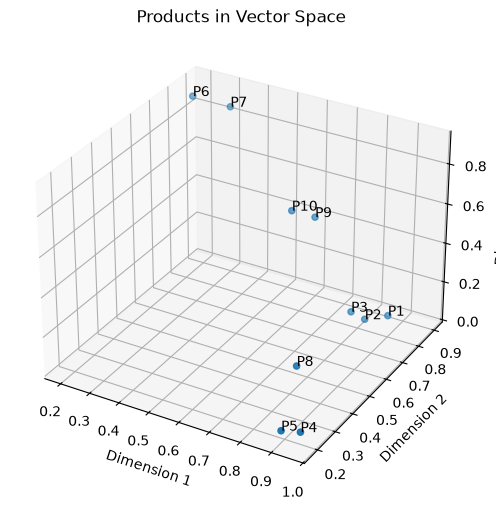

In [5]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(product_vectors[:, 0], product_vectors[:, 1], product_vectors[:, 2])

for i, product_id in enumerate(product_ids):
    ax.text(product_vectors[i, 0], product_vectors[i, 1], product_vectors[i, 2], product_id)

ax.set_xlabel('Dimension 1')
ax.set_ylabel('Dimension 2')
ax.set_zlabel('Dimension 3')
ax.set_title('Products in Vector Space')
plt.show()


# 3. User History

Suppose customer U1 has interacted with:
- iPhone 15
- AirPods Pro
- iPad Air
- MacBook Air M2

In [34]:
user_history = ['P1', 'P7', 'P8', 'P4']

products_df[products_df['product_id'].isin(user_history)]


,product_id,product_name
0,P1,iPhone 15
3,P4,MacBook Air M2
6,P7,AirPods Pro
7,P8,iPad Air


# 4. From User History → User Vector

For this toy model, we represent the user by averaging the vectors of the products they interacted with.

Real systems can use interaction weights, timestamps, purchases, clicks, learned user embeddings, or sequence models.

In [41]:
history_products = products_df[products_df['product_id'].isin(user_history)].copy()

history_products['product_vector'] = list(product_vectors[history_indices])

display(history_products)
history_indices = [product_ids.index(product_id) for product_id in user_history]
selected_vectors = product_vectors[history_indices]

expression = " + ".join(str(vector) for vector in selected_vectors)
expression = f"({expression}) / {len(selected_vectors)}"

user_vector = selected_vectors.mean(axis=0)

print("User vector =", expression)
print("           =", user_vector)


,product_id,product_name,product_vector
0,P1,iPhone 15,"[0.9, 0.8, 0.1]"
3,P4,MacBook Air M2,"[0.3, 0.9, 0.85]"
6,P7,AirPods Pro,"[0.85, 0.35, 0.2]"
7,P8,iPad Air,"[0.95, 0.2, 0.05]"


User vector = ([0.9 0.8 0.1] + [0.3  0.9  0.85] + [0.85 0.35 0.2 ] + [0.95 0.2  0.05]) / 4
           = [0.75   0.5625 0.3   ]


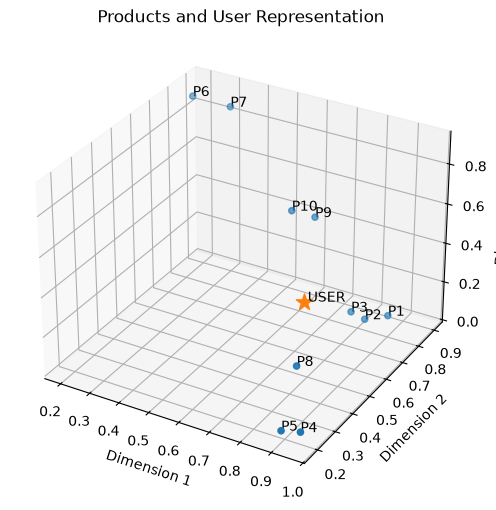

In [8]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(product_vectors[:, 0], product_vectors[:, 1], product_vectors[:, 2])
ax.scatter(user_vector[0], user_vector[1], user_vector[2], s=150, marker='*')

for i, product_id in enumerate(product_ids):
    ax.text(product_vectors[i, 0], product_vectors[i, 1], product_vectors[i, 2], product_id)

ax.text(user_vector[0], user_vector[1], user_vector[2], ' USER')
ax.set_xlabel('Dimension 1')
ax.set_ylabel('Dimension 2')
ax.set_zlabel('Dimension 3')
ax.set_title('Products and User Representation')
plt.show()


### So far so good, these are all our products and their vector representations
| Product ID | Product                | Vector               |
| ---------- | ---------------------- | -------------------- |
| P1         | iPhone 15              | `[0.90, 0.80, 0.10]` |
| P2         | Samsung Galaxy S24     | `[0.85, 0.75, 0.10]` |
| P3         | Google Pixel 8         | `[0.82, 0.72, 0.15]` |
| P4         | MacBook Air M2         | `[0.95, 0.20, 0.05]` |
| P5         | Dell XPS 13            | `[0.90, 0.18, 0.05]` |
| P6         | Sony WH-1000XM5        | `[0.20, 0.85, 0.90]` |
| P7         | AirPods Pro            | `[0.30, 0.90, 0.85]` |
| P8         | iPad Air               | `[0.85, 0.35, 0.20]` |
| P9         | Apple Watch Series 9   | `[0.65, 0.80, 0.50]` |
| P10        | Samsung Galaxy Watch 6 | `[0.60, 0.75, 0.55]` |

### out of these 
| Product ID | Product        | Vector               |
| ---------- | -------------- | -------------------- |
| P1         | iPhone 15      | `[0.90, 0.80, 0.10]` |
| P7         | AirPods Pro    | `[0.30, 0.90, 0.85]` |
| P8         | iPad Air       | `[0.85, 0.35, 0.20]` |
| P4         | MacBook Air M2 | `[0.95, 0.20, 0.05]` |

are the ones user has interacted with. 

our user's vector is `[0.75, 0.5625, 0.3]`




# 5. KNN — Candidate Retrieval

**KNN = K Nearest Neighbors.**

Given a point, KNN finds the K closest points.

For our recommender:

User vector → KNN → candidate products

We will request K = 5, so KNN reduces the 10-product search space to 5 candidates.

In [9]:
knn = NearestNeighbors(
    n_neighbors=5,
    metric='cosine'
)

knn.fit(product_vectors)


,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'cosine'
,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"radius radius: float, default=1.0Range of parameter space to use by default for :meth:`radius_neighbors`queries.",1.0
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float (positive), default=2Parameter for the Minkowski metric fromsklearn.metrics.pairwise.pairwise_distances. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
Name,Type,Value
effective_metric_ effective_metric_: strMetric used to compute distances to neighbors.,str,'cosine'
effective_metric_params_ effective_metric_params_: dictParameters for the metric used to compute distances to neighbors.,dict,{}


### What does `fit()` mean here?

This is not neural-network training. We are giving the KNN object the product dataset against which it will perform neighbor searches.

In [10]:
distances, indices = knn.kneighbors(
    user_vector.reshape(1, -1)
)

distances = distances[0]
indices = indices[0]

for index, distance in zip(indices, distances):
    product_id = product_ids[index]
    print(product_id, '-', products[product_id], '| distance =', round(distance, 4))


P3 - Google Pixel 8 | distance = 0.0177
P2 - Samsung Galaxy S24 | distance = 0.0275
P1 - iPhone 15 | distance = 0.0289
P8 - iPad Air | distance = 0.0342
P9 - Apple Watch Series 9 | distance = 0.0356


# 6. Distance vs Similarity

Cosine distance behaves as:

- smaller distance → more similar
- larger distance → less similar

For easier interpretation in this toy example:

`similarity = 1 - distance`

In [11]:
candidate_ids = [product_ids[index] for index in indices]

similarity_scores = {
    product_id: 1 - distance
    for product_id, distance in zip(candidate_ids, distances)
}

similarity_df = pd.DataFrame({
    'product_id': candidate_ids,
    'product': [products[p] for p in candidate_ids],
    'similarity': [similarity_scores[p] for p in candidate_ids]
})

similarity_df


,product_id,product,similarity
0,P3,Google Pixel 8,0.982256
1,P2,Samsung Galaxy S24,0.972527
2,P1,iPhone 15,0.971102
3,P8,iPad Air,0.965844
4,P9,Apple Watch Series 9,0.964359


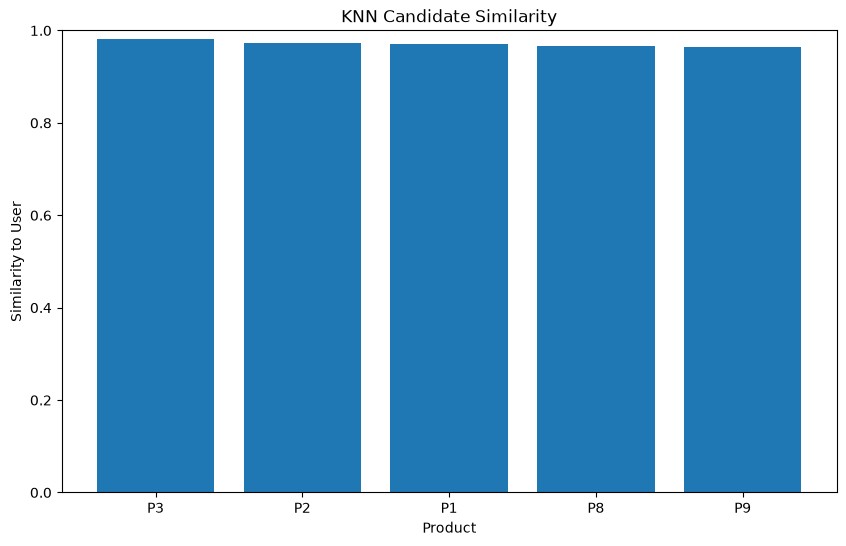

In [12]:
plt.bar(similarity_df['product_id'], similarity_df['similarity'])
plt.xlabel('Product')
plt.ylabel('Similarity to User')
plt.title('KNN Candidate Similarity')
plt.ylim(0, 1)
plt.show()


# 7. Remove Already-Seen Products

KNN may retrieve products the customer has already interacted with. For this recommendation scenario, we will exclude them before the final recommendation stage.

In [13]:
candidate_ids = [
    product_id
    for product_id in candidate_ids
    if product_id not in user_history
]

candidate_df = pd.DataFrame({
    'product_id': candidate_ids,
    'product': [products[p] for p in candidate_ids],
    'similarity': [similarity_scores[p] for p in candidate_ids]
})

candidate_df


,product_id,product,similarity
0,P3,Google Pixel 8,0.982256
1,P2,Samsung Galaxy S24,0.972527
2,P9,Apple Watch Series 9,0.964359


# 8. Multiple Ranking Signals

KNN tells us which products are relevant enough to consider. We now introduce other signals that may disagree with similarity.

We will use:
1. Similarity
2. Popularity
3. User behavior relevance

These values are manually created in this toy notebook so we can focus on understanding rank fusion.

In [14]:
popularity = {
    'P2': 0.95,
    'P3': 0.80,
    'P5': 0.50,
    'P6': 0.85,
    'P9': 0.75,
    'P10': 0.65
}

behavior = {
    'P2': 0.60,
    'P3': 0.40,
    'P5': 0.30,
    'P6': 0.65,
    'P9': 0.75,
    'P10': 0.55
}


In [15]:
ranking_df = pd.DataFrame({
    'product_id': candidate_ids,
    'product': [products[p] for p in candidate_ids],
    'similarity': [similarity_scores[p] for p in candidate_ids],
    'popularity': [popularity[p] for p in candidate_ids],
    'behavior': [behavior[p] for p in candidate_ids]
})

ranking_df


,product_id,product,similarity,popularity,behavior
0,P3,Google Pixel 8,0.982256,0.80,0.40
1,P2,Samsung Galaxy S24,0.972527,0.95,0.60
2,P9,Apple Watch Series 9,0.964359,0.75,0.75


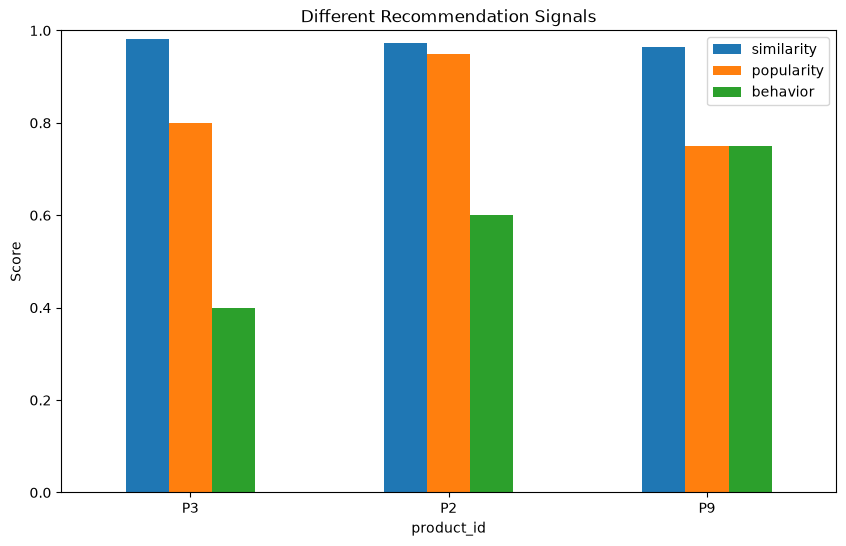

In [16]:
ranking_df.set_index('product_id')[['similarity', 'popularity', 'behavior']].plot(kind='bar')
plt.ylabel('Score')
plt.title('Different Recommendation Signals')
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.show()


# 9. Convert Scores → Rankings

Each signal can produce a different ordering of the same candidates. Rank fusion will combine these orderings.

In [17]:
similarity_ranking = ranking_df.sort_values('similarity', ascending=False)['product_id'].tolist()
popularity_ranking = ranking_df.sort_values('popularity', ascending=False)['product_id'].tolist()
behavior_ranking = ranking_df.sort_values('behavior', ascending=False)['product_id'].tolist()

print('Similarity :', similarity_ranking)
print('Popularity :', popularity_ranking)
print('Behavior   :', behavior_ranking)


Similarity : ['P3', 'P2', 'P9']
Popularity : ['P2', 'P3', 'P9']
Behavior   : ['P9', 'P2', 'P3']


In [18]:
rank_table = pd.DataFrame({
    'Similarity': similarity_ranking,
    'Popularity': popularity_ranking,
    'Behavior': behavior_ranking
})

rank_table


,Similarity,Popularity,Behavior
0,P3,P2,P9
1,P2,P3,P2
2,P9,P9,P3


# 10. Reciprocal Rank Fusion (RRF)

RRF combines multiple rankings into one ranking.

Formula:

`RRF score = 1 / (k + rank)`

We use `k = 60`.

A product receives more points when it appears near the top of a ranking. If it appears near the top of several rankings, those contributions add together.

In [ ]:
def reciprocal_rank_fusion(rankings, k=60):
    scores = {}

    for ranking in rankings:
        for rank, product_id in enumerate(ranking, start=1):
            score = 1 / (k + rank)
            scores[product_id] = scores.get(product_id, 0) + score

    return scores 


rrf_scores = reciprocal_rank_fusion([
    similarity_ranking,
    popularity_ranking,
    behavior_ranking
])

rrf_scores


{'P3': 0.04839549075403121,
 'P2': 0.048651507139079855,
 'P9': 0.04813947436898257}

# 11. Inspect One Product's RRF Score

This cell makes RRF concrete: we can see where a product ranked in each signal and how much each rank contributed.

In [20]:
product_to_explain = candidate_ids[0]

print('Product:', product_to_explain)
print(products[product_to_explain])

for name, ranking in [
    ('Similarity', similarity_ranking),
    ('Popularity', popularity_ranking),
    ('Behavior', behavior_ranking)
]:
    rank = ranking.index(product_to_explain) + 1
    print(name, 'rank =', rank, 'contribution =', round(1 / (60 + rank), 6))

print('Final RRF =', round(rrf_scores[product_to_explain], 6))


Product: P3
Google Pixel 8
Similarity rank = 1 contribution = 0.016393
Popularity rank = 2 contribution = 0.016129
Behavior rank = 3 contribution = 0.015873
Final RRF = 0.048395


# 12. Final Ranking

Now sort the candidates by their combined RRF score.

In [21]:
final_ranking = sorted(
    rrf_scores,
    key=rrf_scores.get,
    reverse=True
)

final_df = pd.DataFrame({
    'rank': range(1, len(final_ranking) + 1),
    'product_id': final_ranking,
    'product': [products[p] for p in final_ranking],
    'rrf_score': [rrf_scores[p] for p in final_ranking]
})

final_df


,rank,product_id,product,rrf_score
0,1,P2,Samsung Galaxy S24,0.048652
1,2,P3,Google Pixel 8,0.048395
2,3,P9,Apple Watch Series 9,0.048139


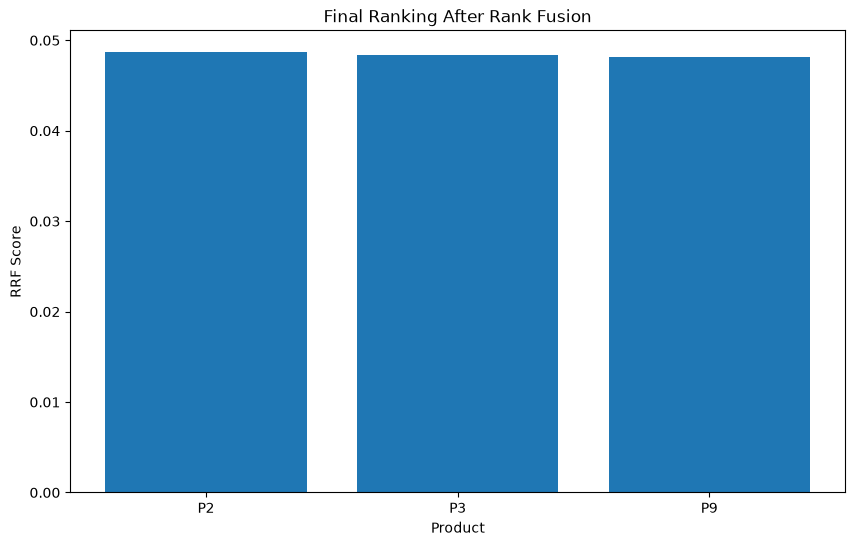

In [22]:
plt.bar(final_df['product_id'], final_df['rrf_score'])
plt.xlabel('Product')
plt.ylabel('RRF Score')
plt.title('Final Ranking After Rank Fusion')
plt.show()


# 13. Final Top 3 Recommendations

In [23]:
top_3 = final_ranking[:3]

recommendations = pd.DataFrame({
    'position': range(1, 4),
    'product_id': top_3,
    'recommended_product': [products[p] for p in top_3]
})

recommendations


,position,product_id,recommended_product
0,1,P2,Samsung Galaxy S24
1,2,P3,Google Pixel 8
2,3,P9,Apple Watch Series 9


# 14. Final Mental Model

### Stage 1 — Representation
Products → vectors

User history → user vector

### Stage 2 — Retrieval
User vector → KNN → candidate products

### Stage 3 — Ranking Signals
Candidates → similarity + popularity + behavior → separate rankings

### Stage 4 — Rank Fusion
Multiple rankings → RRF → one unified ranking

### Stage 5 — Recommendation
Unified ranking → top 3 → customer

## The core idea

**KNN answers:** "Which products are worth considering?"

**Rank fusion answers:** "Considering multiple signals, which candidates should appear first?"